#### Import Packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
from collections import Counter

#### Load the file

In [4]:
data = pd.read_csv("/content/drive/MyDrive/chatgpt_style_reviews_dataset.csv")
data.head(5)

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


#### Remove unwanted data

In [5]:
c_data = data.drop(columns=['username', 'title'])
c_data.head()

,date,review,rating,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,"Not satisfied, many bugs and issues.",1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Amazing quality and user-friendly interface.,5,180,5,Flipkart,zh,France,1.2.3,No
2,########,"Terrible experience, needs major improvements.",2,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Poor performance and not user-friendly.,1,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,"Not satisfied, many bugs and issues.",2,139,6,Website,ar,Kenya,2.1.4,No


In [6]:
c_data['date'].unique()

array(['########', '5/5/2024', '3/9/2024', '3/8/2024', '6/2/2024',
       '6/5/2024', '1/3/2025', '7/1/2024', '4/8/2025', '2/9/2024',
       '8/6/2024', '3/1/2024', '9/2/2024', '6/1/2024', '4/9/2024',
       '3/7/2025', '3/2/2024', '3/7/2024', '2/8/2025', '5/9/2025',
       '2/7/2024', '5/3/2025', '2/4/2025', '5/2/2025', '4/3/2024',
       '5/4/2025', '7/2/2024', '2/1/2025', '4/4/2025', '7/3/2024',
       '2/1/2024', '2/2/2025', '3/3/2025', '1/2/2025', '4/9/2025',
       '7/8/2024', '2/4/2024', '1/2/2024', '5/8/2024', '6/8/2024',
       '1/3/2024', '2/6/2024', '5/8/2025', '4/2/2025', '9/7/2024',
       '1/6/2024', '2/3/2024', '4/7/2025', '5/5/2025', '9/3/2024',
       '8/8/2024', '8/2/2024', '1/9/2024', '8/9/2024', '1/5/2024',
       '6/6/2024', '9/8/2024', '9/9/2024', '8/7/2024', '9/6/2024',
       '1/8/2025', '6/4/2024', '2/2/2024', '5/6/2024', '1/7/2025',
       '5/4/2024', '3/8/2025', '1/9/2025', '1/6/2025', '4/6/2024',
       '3/9/2025', '1/1/2024', '1/4/2024', '2/5/2025', '7/9/20

#### Imputation - Date

In [7]:
c_data['date'] = c_data['date'].replace('########', np.nan)
c_data['date'] = c_data['date'].ffill().bfill()
c_data.head()

,date,review,rating,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,5/5/2024,"Not satisfied, many bugs and issues.",1,80,6,Amazon,zh,Kenya,2.1.4,No
1,5/5/2024,Amazing quality and user-friendly interface.,5,180,5,Flipkart,zh,France,1.2.3,No
2,5/5/2024,"Terrible experience, needs major improvements.",2,154,5,Flipkart,pt,USA,1.2.3,No
3,5/5/2024,Poor performance and not user-friendly.,1,96,5,Amazon,es,Qatar,2.1.4,Yes
4,5/5/2024,"Not satisfied, many bugs and issues.",2,139,6,Website,ar,Kenya,2.1.4,No


#### Preprocessing - Platform

In [8]:
c_data['platform'].unique()

array(['Amazon', 'Flipkart', 'Website', 'App Store', 'Google Play'],
      dtype=object)

In [10]:
c_data['platform'] = c_data['platform'].replace(['Amazon', 'Flipkart', 'App Store', 'Google Play'], 'Mobile')
c_data['platform'].head()

,platform
0,Mobile
1,Mobile
2,Mobile
3,Mobile
4,Website


#### What is the distribution of review ratings?

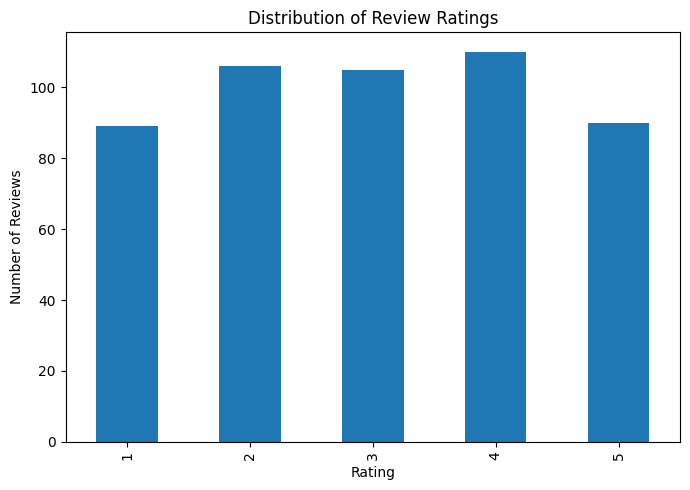

In [11]:
rating_counts = c_data['rating'].value_counts().sort_index()

# Plot
plt.figure(figsize=(7, 5))
rating_counts.plot(kind='bar')

plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Review Ratings')
plt.tight_layout()

plt.show()

#### How many reviews were marked as helpful?

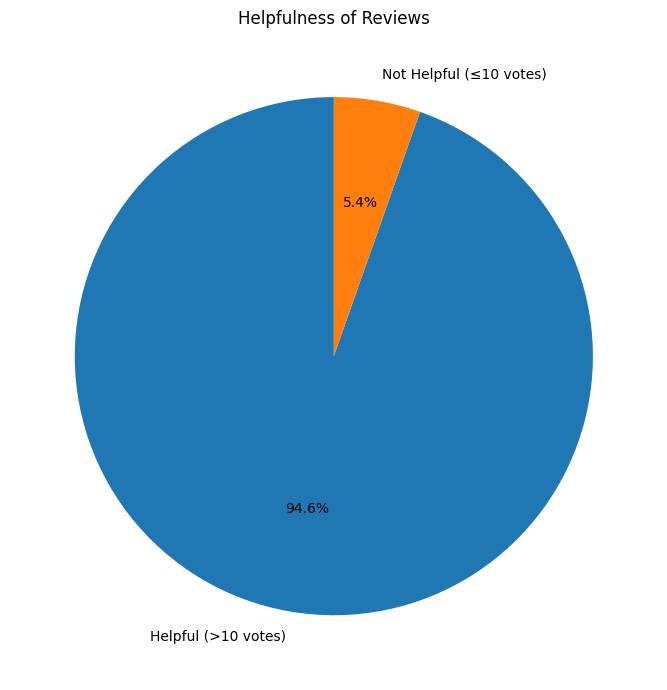

In [12]:
threshold = 10
helpful_counts = {
    'Helpful (>10 votes)': (c_data['helpful_votes'] > threshold).sum(),
    'Not Helpful (≤10 votes)': (c_data['helpful_votes'] <= threshold).sum()
}
plt.figure(figsize=(7, 7))
plt.pie(
    helpful_counts.values(),
    labels=helpful_counts.keys(),
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Helpfulness of Reviews')
plt.tight_layout()
plt.show()

#### What are the most common keywords in positive vs. negative reviews?

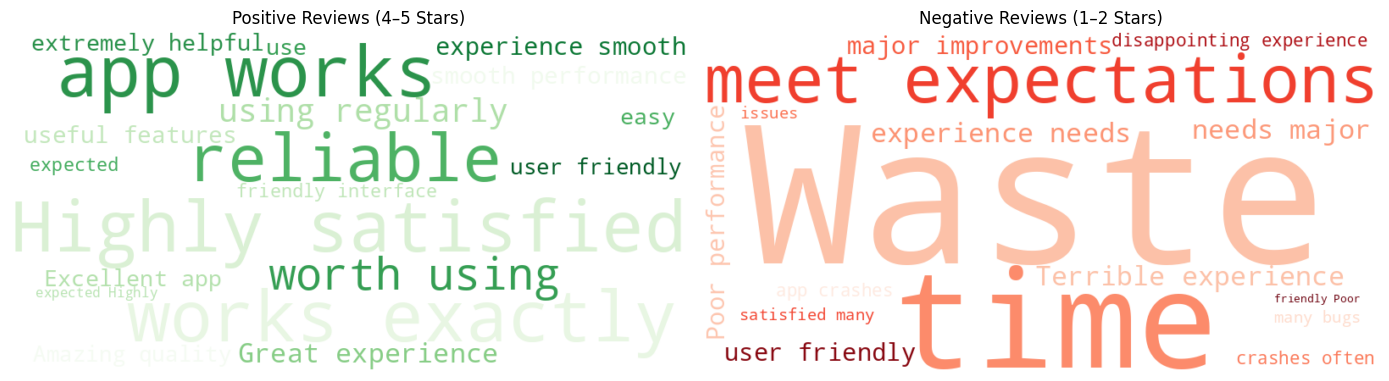

In [13]:
positive_reviews = c_data[c_data['rating'].isin([4, 5])]['review']
negative_reviews = c_data[c_data['rating'].isin([1, 2])]['review']
positive_text = ' '.join(positive_reviews.dropna().astype(str))
negative_text = ' '.join(negative_reviews.dropna().astype(str))
pos_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate(positive_text)

neg_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(negative_text)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(pos_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews (4–5 Stars)')

plt.subplot(1, 2, 2)
plt.imshow(neg_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews (1–2 Stars)')

plt.tight_layout()
plt.show()


#### How has the average rating changed over time?

/tmp/ipython-input-2363902509.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = c_data.groupby(pd.Grouper(key='date', freq='M'))['rating'].mean()


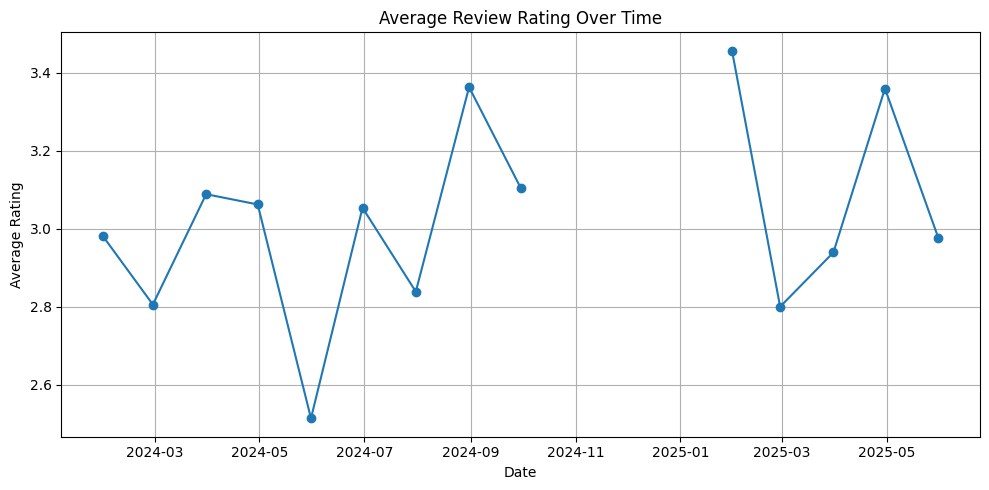

In [14]:
c_data['date'] = pd.to_datetime(c_data['date'], errors='coerce')
monthly_avg = c_data.groupby(pd.Grouper(key='date', freq='M'))['rating'].mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.title('Average Review Rating Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

#### How do ratings vary by user location?

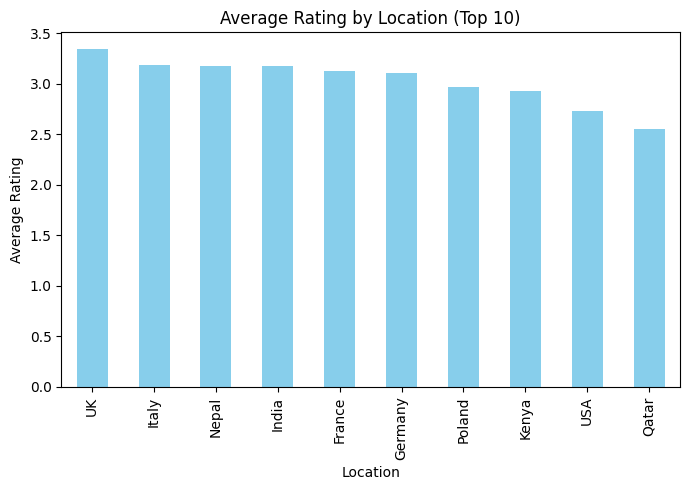

In [15]:
location_avg = c_data.groupby('location')['rating'].mean().sort_values(ascending=False)
top_locations = location_avg.head(10)
plt.figure(figsize=(7, 5))
top_locations.plot(kind='bar', color='skyblue')
plt.xlabel('Location')
plt.ylabel('Average Rating')
plt.title('Average Rating by Location (Top 10)')
plt.tight_layout()
plt.show()

#### Which platform (Web vs Mobile) gets better reviews?

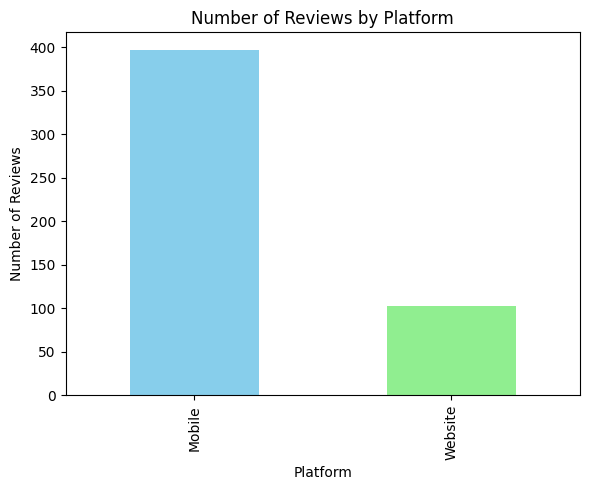

In [16]:
platform_counts = c_data.groupby('platform')['rating'].count()

plt.figure(figsize=(6,5))
platform_counts.plot(kind='bar', color=['skyblue', 'lightgreen'])

plt.xlabel('Platform')
plt.ylabel('Number of Reviews')   # <-- fix
plt.title('Number of Reviews by Platform')  # <-- fix
plt.tight_layout()
plt.show()

#### Are verified users more satisfied than non-verified ones?

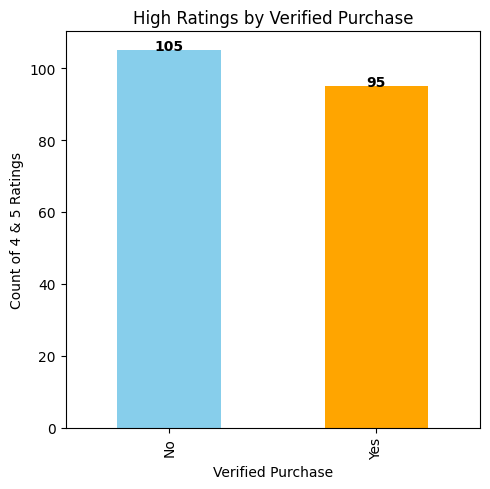

In [17]:
high_ratings = c_data[c_data['rating'].isin([4, 5])]
verified_counts = high_ratings['verified_purchase'].value_counts()
plt.figure(figsize=(5,5))
ax = verified_counts.plot(kind='bar', color=['skyblue', 'orange'])
for i, count in enumerate(verified_counts.values):
    ax.text(i,count , str(count), ha='center', fontweight='bold')
plt.xlabel('Verified Purchase')
plt.ylabel('Count of 4 & 5 Ratings')
plt.title('High Ratings by Verified Purchase')
plt.tight_layout()
plt.show()


#### What’s the average length of reviews per rating category?

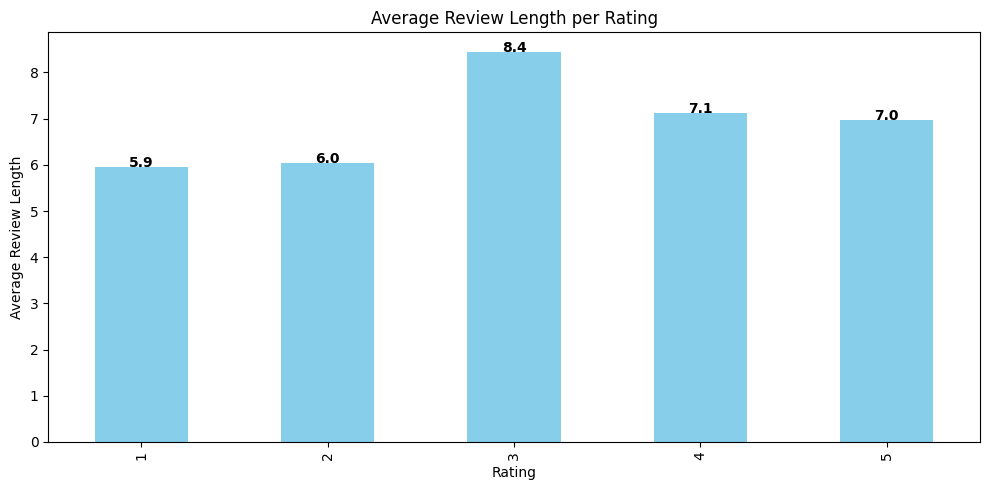

In [18]:
avg_length = c_data.groupby('rating')['review_length'].mean()

plt.figure(figsize=(10,5))
ax = avg_length.plot(kind='bar', color='skyblue')

for i, v in enumerate(avg_length.values):
    ax.text(i, v , f"{v:.1f}", ha='center', fontweight='bold')

plt.xlabel('Rating')
plt.ylabel('Average Review Length')
plt.title('Average Review Length per Rating')
plt.tight_layout()
plt.show()

#### What are the most mentioned words in 1-star reviews?

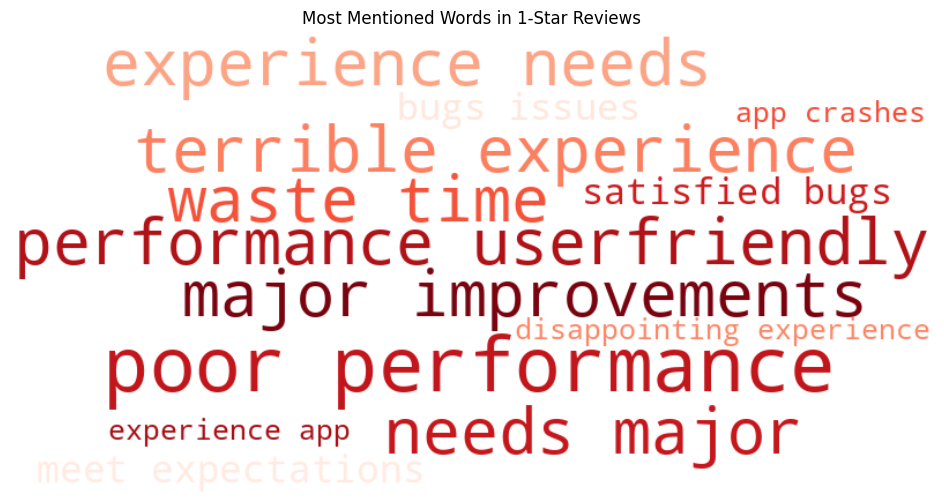

In [19]:
one_star_reviews = c_data[c_data['rating'] == 1]['review'].astype(str)
def preprocess(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    words = [word for word in text.split() if word not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

cleaned_text = one_star_reviews.apply(preprocess)
text_combined = ' '.join(cleaned_text)

wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_combined)

plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Mentioned Words in 1-Star Reviews')
plt.show()

#### What ChatGPT version received the highest average rating?

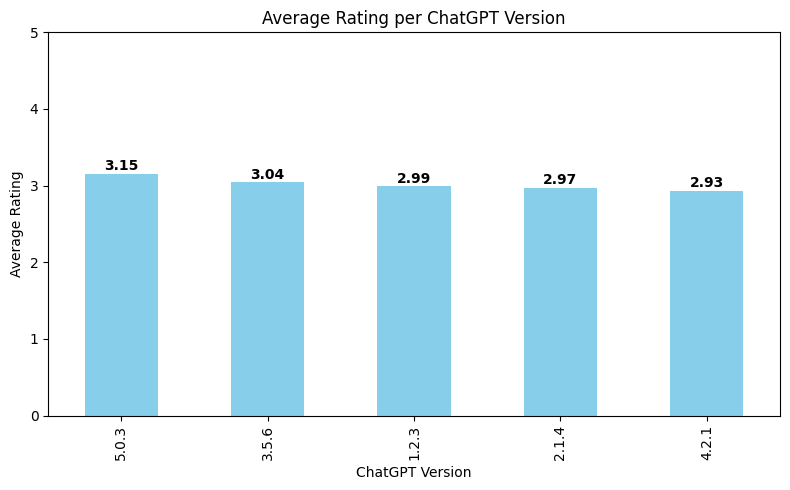

In [20]:
version_avg = c_data.groupby('version')['rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
ax = version_avg.plot(kind='bar', color='skyblue')

# Display average rating on top of each bar
for i, v in enumerate(version_avg.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontweight='bold')

plt.xlabel('ChatGPT Version')
plt.ylabel('Average Rating')
plt.title('Average Rating per ChatGPT Version')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

#### 1.What is the overall sentiment of user reviews?

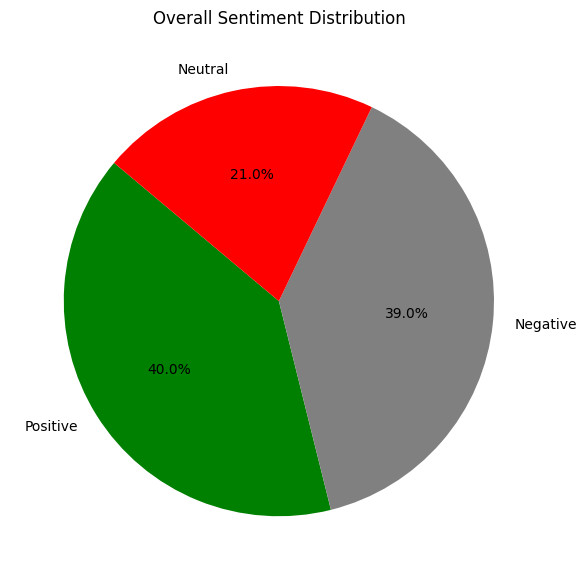

In [21]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

sentiment_series = c_data['rating'].apply(
    lambda x: 'Negative' if x <= 2 else 'Neutral' if x == 3 else 'Positive'
)
sentiment_counts = sentiment_series.value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['green', 'gray', 'red']
)

plt.title('Overall Sentiment Distribution')
plt.tight_layout()
plt.show()

#### 2.How does sentiment vary by rating?

In [22]:
# Temporary sentiment mapping
sentiment_series = c_data['rating'].apply(
    lambda x: 'Negative' if x <= 2 else 'Neutral' if x == 3 else 'Positive'
)

# Filter only 1-star and 2-star reviews
low_rating_mask = c_data['rating'].isin([1, 2])
low_rating_sentiments = sentiment_series[low_rating_mask]

# Total count
total_low_ratings = low_rating_sentiments.shape[0]

# Mismatches: Neutral or Positive sentiment
mismatch_count = low_rating_sentiments.isin(['Neutral', 'Positive']).sum()

# Mismatch percentage
mismatch_percentage = (mismatch_count / total_low_ratings) * 100

print(f"Total ratings: {total_low_ratings}, "
    f"Mismatch count: {mismatch_count}, "
    f"Mismatch %: {round(mismatch_percentage, 2)}")

Total ratings: 195, Mismatch count: 0, Mismatch %: 0.0


#### 3.Which keywords or phrases are most associated with each sentiment class?

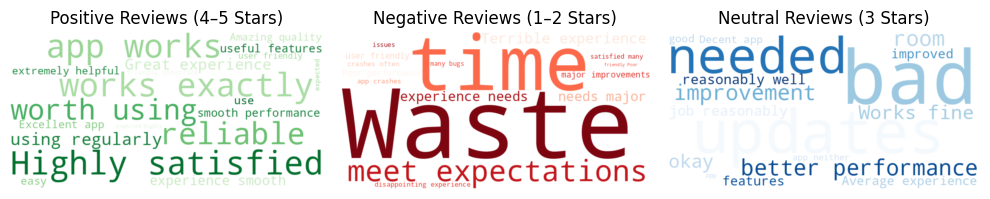

In [23]:
positive_reviews = c_data[c_data['rating'].isin([4, 5])]['review']
negative_reviews = c_data[c_data['rating'].isin([1, 2])]['review']
neutral_reviews = c_data[c_data['rating'].isin([3])]['review']
positive_text = ' '.join(positive_reviews.dropna().astype(str))
negative_text = ' '.join(negative_reviews.dropna().astype(str))
neutral_text = ' '.join(neutral_reviews.dropna().astype(str))
pos_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate(positive_text)

neg_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(negative_text)

neu_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Blues'
).generate(neutral_text)

plt.figure(figsize=(10,7))

plt.subplot(1, 3, 1)
plt.imshow(pos_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews (4–5 Stars)')

plt.subplot(1, 3, 2)
plt.imshow(neg_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews (1–2 Stars)')

plt.subplot(1, 3, 3)
plt.imshow(neu_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Neutral Reviews (3 Stars)')

plt.tight_layout()
plt.show()

#### 4.How has sentiment changed over time?

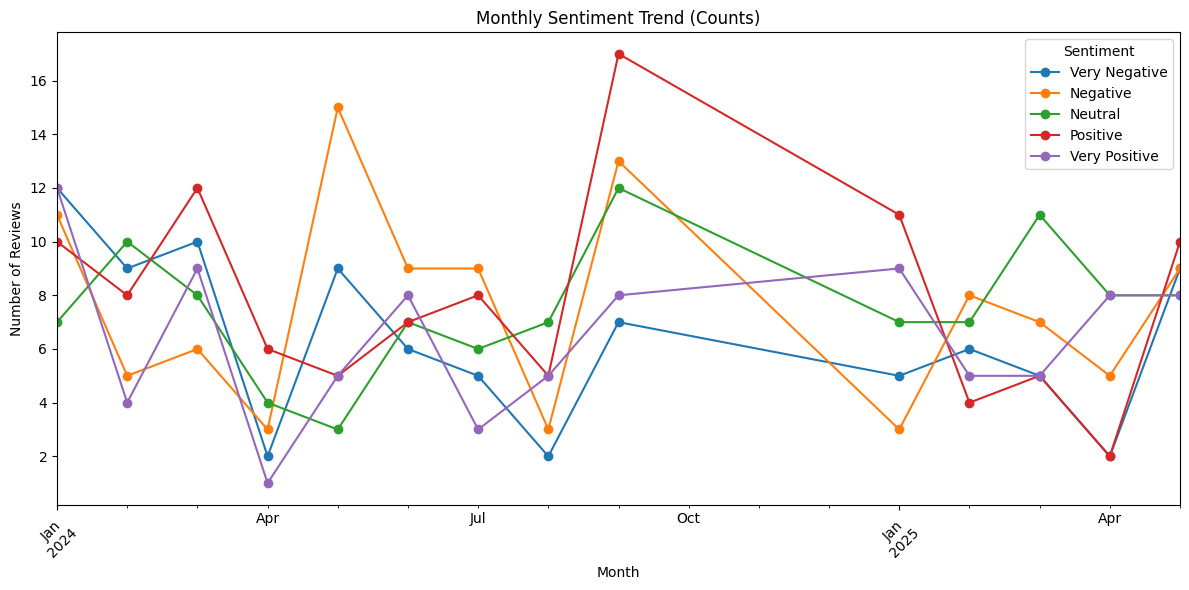

In [24]:
# Convert to datetime
c_data['date'] = pd.to_datetime(c_data['date'])

# Create time features
c_data['year'] = c_data['date'].dt.year
c_data['month'] = c_data['date'].dt.to_period('M')
c_data['week'] = c_data['date'].dt.to_period('W')
monthly_counts = (
    c_data.groupby(['month', 'rating'])
      .size()
      .unstack(fill_value=0)
)

monthly_counts.plot(figsize=(12,6), marker='o')
plt.title("Monthly Sentiment Trend (Counts)")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(
    title="Sentiment",
    labels=[
        "Very Negative",
        "Negative",
        "Neutral",
        "Positive",
        "Very Positive"
    ]
)
plt.tight_layout()
plt.show()

#### 5.Do verified users tend to leave more positive or negative reviews?

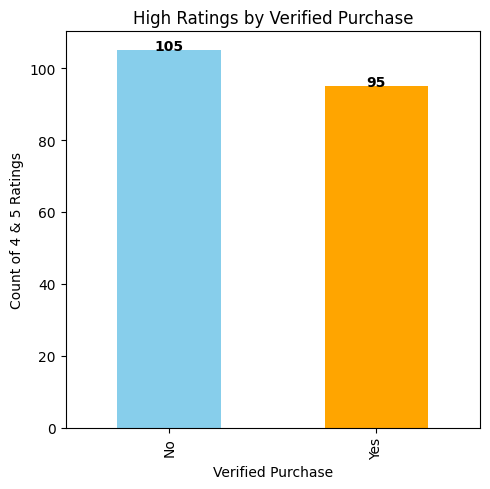

In [25]:
high_ratings = c_data[c_data['rating'].isin([4, 5])]
verified_counts = high_ratings['verified_purchase'].value_counts()
plt.figure(figsize=(5,5))
ax = verified_counts.plot(kind='bar', color=['skyblue', 'orange'])
for i, count in enumerate(verified_counts.values):
    ax.text(i,count , str(count), ha='center', fontweight='bold')
plt.xlabel('Verified Purchase')
plt.ylabel('Count of 4 & 5 Ratings')
plt.title('High Ratings by Verified Purchase')
plt.tight_layout()
plt.show()

#### 6.Are longer reviews more likely to be negative or positive?

/tmp/ipython-input-16105111.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_length,


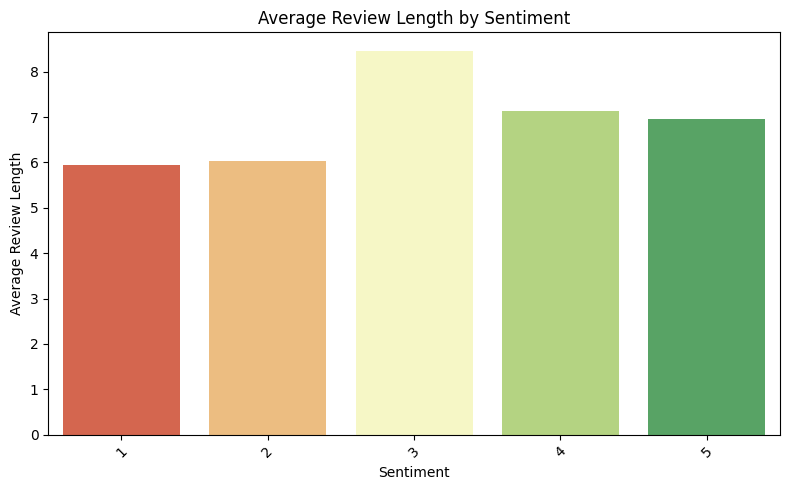

In [26]:
avg_length = (
    c_data.groupby('rating')['review_length']
          .mean()
          .reset_index()
)

#print(avg_length)
plt.figure(figsize=(8,5))
sns.barplot(data=avg_length,
            x='rating',
            y='review_length',
            palette='RdYlGn')

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Review Length")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 7.Which locations show the most positive or negative sentiment?

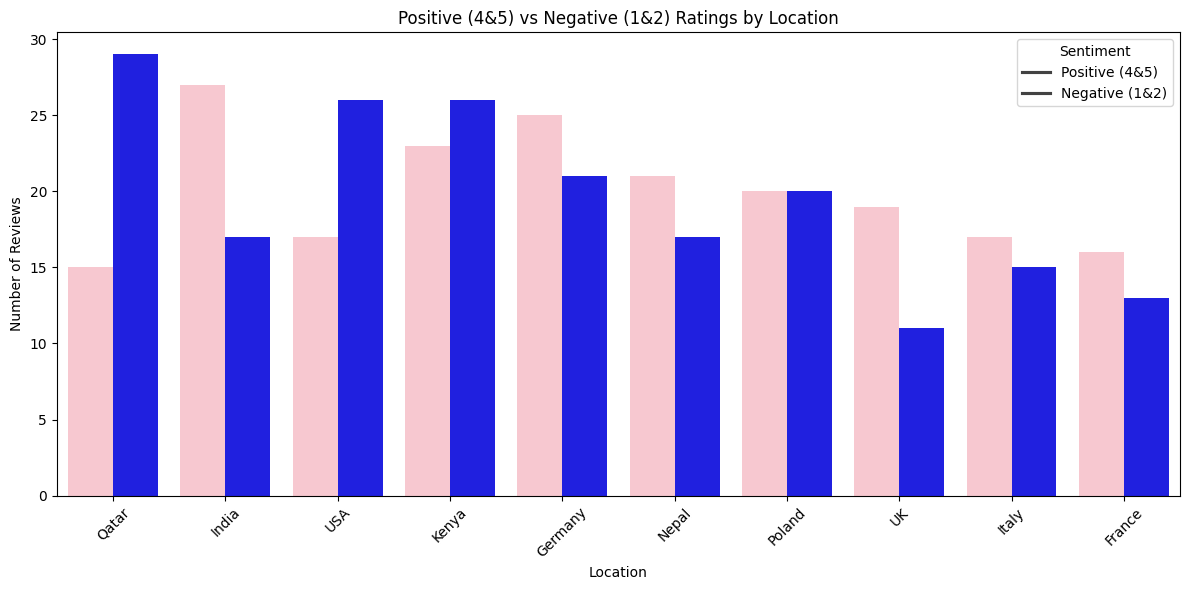

In [27]:
# Create flags
c_data['positive'] = c_data['rating'].isin([4, 5])
c_data['negative'] = c_data['rating'].isin([1, 2])
location_counts = (
    c_data.groupby('location')
          .agg(
              positive_count=('positive', 'sum'),
              negative_count=('negative', 'sum')
          )
          .reset_index()
)
# Add total review count
location_counts['total_reviews'] = (
    location_counts['positive_count'] + location_counts['negative_count']
)

# Filter locations with enough reviews
location_counts = location_counts[location_counts['total_reviews'] > 20]
location_counts['max_sentiment'] = location_counts[
    ['positive_count', 'negative_count']
].max(axis=1)

location_counts = location_counts.sort_values(
    by='max_sentiment', ascending=False
)
plot_data = location_counts.melt(
    id_vars='location',
    value_vars=['positive_count', 'negative_count'],
    var_name='Sentiment_Type',
    value_name='Count'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_data,
    x='location',
    y='Count',
    hue='Sentiment_Type',
    palette=['pink', 'blue']
)

plt.title("Positive (4&5) vs Negative (1&2) Ratings by Location")
plt.xlabel("Location")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment",
           labels=['Positive (4&5)', 'Negative (1&2)'])

plt.tight_layout()
plt.show()

#### 8.Is there a difference in sentiment across platforms (Web vs Mobile)?

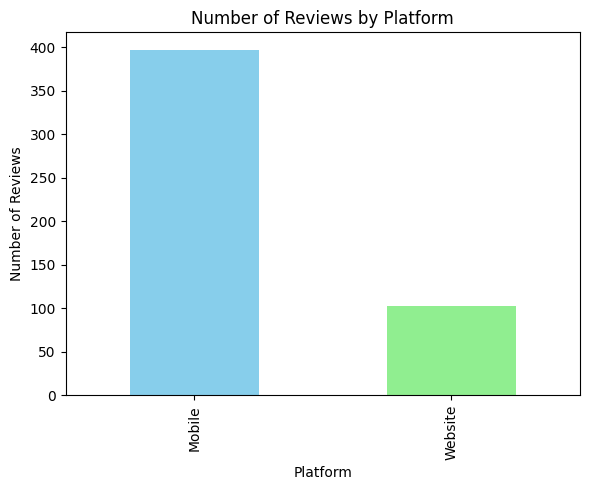

In [28]:
platform_counts = c_data.groupby('platform')['rating'].count()

plt.figure(figsize=(6,5))
platform_counts.plot(kind='bar', color=['skyblue', 'lightgreen'])

plt.xlabel('Platform')
plt.ylabel('Number of Reviews')   # <-- fix
plt.title('Number of Reviews by Platform')  # <-- fix
plt.tight_layout()
plt.show()

#### 9.Which ChatGPT versions are associated with higher/lower sentiment?


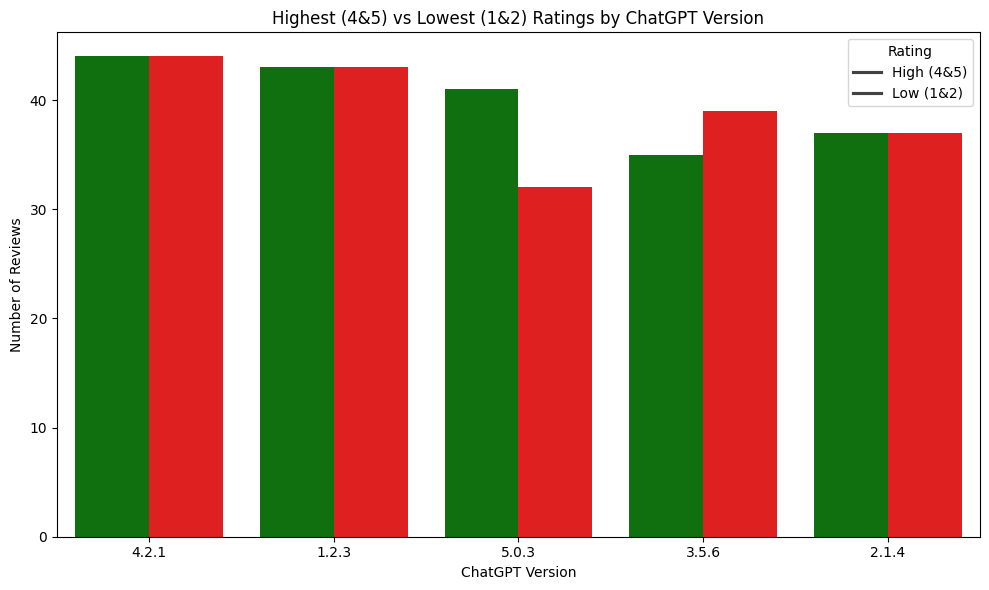

In [29]:
# Create flags
c_data['high_rating'] = c_data['rating'].isin([4, 5])
c_data['low_rating'] = c_data['rating'].isin([1, 2])
version_counts = (
    c_data.groupby('version')
          .agg(
              high_count=('high_rating', 'sum'),
              low_count=('low_rating', 'sum'),
              total_reviews=('rating', 'count')
          )
          .reset_index()
)
version_counts = version_counts[version_counts['total_reviews'] > 20]
version_counts['max_impact'] = version_counts[['high_count','low_count']].max(axis=1)

version_counts = version_counts.sort_values(by='max_impact', ascending=False)
plot_data = version_counts.melt(
    id_vars='version',
    value_vars=['high_count', 'low_count'],
    var_name='Rating_Type',
    value_name='Count'
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_data,
    x='version',
    y='Count',
    hue='Rating_Type',
    palette=['green', 'red']
)

plt.title("Highest (4&5) vs Lowest (1&2) Ratings by ChatGPT Version")
plt.xlabel("ChatGPT Version")
plt.ylabel("Number of Reviews")
plt.legend(title="Rating",
           labels=['High (4&5)', 'Low (1&2)'])

plt.tight_layout()
plt.show()

#### 10.What are the most common negative feedback themes?

Number of negative reviews: 195
             word  count
6      experience     79
4            does     43
5    expectations     43
16           time     43
18          waste     43
10           meet     43
11          needs     41
15       terrible     41
13           poor     41
9           major     41
7    improvements     41
17   userfriendly     41
12    performance     41
0             app     38
2         crashes     38
3   disappointing     38
1            bugs     32
8          issues     32
14      satisfied     32
                  Theme  Count
1                 Other    125
0      Technical Errors     70
2    Performance Issues      0
3       Accuracy Issues      0
4  Login/Account Issues      0
5  Subscription/Billing      0
6      Limited Features      0


/tmp/ipython-input-1177656956.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=theme_df,


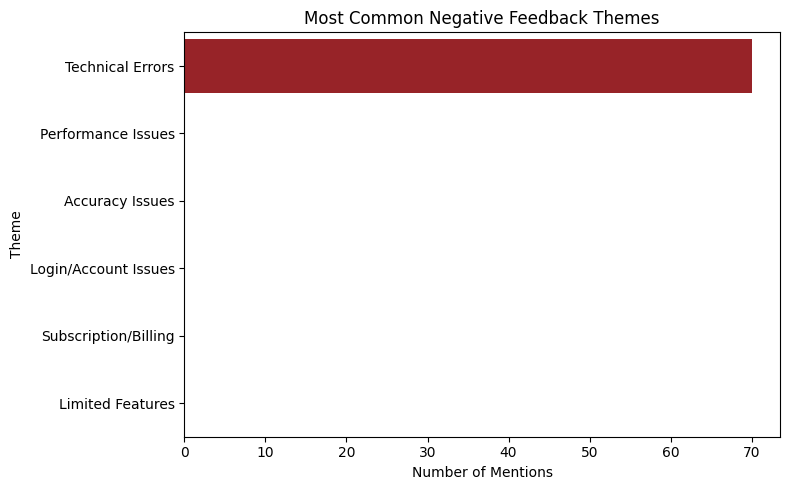

In [42]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

c_data['clean_text'] = c_data['review'].apply(clean_text)
negative_reviews = c_data[c_data['rating'].isin([1, 2])].copy()

print("Number of negative reviews:", len(negative_reviews))
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(negative_reviews['clean_text'])

word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    'word': words,
    'count': word_counts
}).sort_values(by='count', ascending=False)

print(freq_df)
themes = {
    "Technical Errors": [
        "error", "errors", "bug", "bugs", "crash", "crashes",
        "issue", "issues", "problem", "problems", "not working",
        "failed", "failure"
    ],
    "Performance Issues": [
        "slow", "slower", "lag", "lagging", "delay",
        "response time", "takes long", "loading"
    ],
    "Accuracy Issues": [
        "wrong", "incorrect", "inaccurate", "bad answer",
        "nonsense", "irrelevant"
    ],
    "Login/Account Issues": [
        "login", "account", "sign in", "password", "access"
    ],
    "Subscription/Billing": [
        "refund", "charged", "charge", "payment",
        "subscription", "money"
    ],
    "Limited Features": [
        "limited", "limit", "restricted",
        "missing", "feature"
    ]
}

def detect_themes(text):
    matched = []
    for theme, keywords in themes.items():
        for word in keywords:
            if word in text:
                matched.append(theme)
                break
    return matched if matched else ["Other"]

negative_reviews['detected_themes'] = negative_reviews['clean_text'].apply(detect_themes)
all_themes = []

for sublist in negative_reviews['detected_themes']:
    all_themes.extend(sublist)
from collections import Counter

all_themes = []
for sublist in negative_reviews['detected_themes']:
    all_themes.extend(sublist)

theme_counts = Counter(all_themes)

# Ensure ALL themes appear (even if count = 0)
for theme in themes.keys():
    if theme not in theme_counts:
        theme_counts[theme] = 0

theme_df = pd.DataFrame(
    theme_counts.items(),
    columns=['Theme', 'Count']
).sort_values(by='Count', ascending=False)

print(theme_df)
theme_df = theme_df[theme_df['Theme'] != "Other"]

plt.figure(figsize=(8,5))
sns.barplot(data=theme_df,
            x='Count',
            y='Theme',
            palette='Reds_r')

plt.title("Most Common Negative Feedback Themes")
plt.xlabel("Number of Mentions")
plt.ylabel("Theme")
plt.tight_layout()
plt.show()
